In [3]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr
import arviz as az
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)
num_dimensions = 50
num_data = 100
noise_magnitude_on_each_point = 0.1
total_length = 1
def matern_32(r, variance=1.0, scale=total_length/5, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_dimensions - 1)

fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
shape = (num_dimensions, num_dimensions)
dist_matrix = jnp.fromfunction(dist_function, shape)
cov_prior_matrix = matern_32(dist_matrix)
L_K = jnp.linalg.cholesky(cov_prior_matrix)
inv_cov_prior_matrix = jnp.linalg.inv(cov_prior_matrix)


diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)


#observed_indices = jnp.searchsorted(fixed_points_linspace, x_obs)
#R = jnp.zeros((num_data, num_dimensions));
#R = R.at[jnp.arange(num_data), observed_indices].set(1);
R = jax.jacobian(response)(fixed_points_linspace)

# This is the response matrix that takes the white noise behind our GP to observed data values
R_enhanced = R @ L_K

D = cov_prior_matrix - cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ R @ cov_prior_matrix;
M = cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ y_obs
L_D = jnp.linalg.cholesky(D)

def KL_div_between_two_Gaussians(x1, cov1, x2, cov2, num_dimensions):
    L2 = jnp.linalg.cholesky(cov2)
    
    # logdet via Cholesky: logdet(cov2) = 2 * sum(log(diag(L2)))
    logabsdet2 = 2.0 * jnp.sum(jnp.log(jnp.diag(L2)))
    _, logabsdet1 = jnp.linalg.slogdet(cov1)
    
    # trace(cov2^-1 @ cov1) via triangular solves instead of full solve
    solve1 = jax.scipy.linalg.cho_solve((L2, True), cov1)
    trace_term = jnp.trace(solve1)
    
    # mahalanobis term via triangular solve
    diff = x2 - x1
    y = jax.scipy.linalg.solve_triangular(L2, diff, lower=True)
    mahalanobis = jnp.sum(y**2)  # equivalent to y.T @ y, avoids the solve
    
    return 0.5 * (logabsdet2 - logabsdet1 - num_dimensions
                  + trace_term + mahalanobis)

In [4]:
num_overall_steps = 100000
burn_in = 100
def negative_logdensity(x):
    # the first two lines do HMC in actual GP space; the next two do HMC in white noise space
    #negative_log_p_d_given_s = 0.5*(y_obs - R @ x).T @ inv_cov_data_matrix @ (y_obs - R @ x) 
    #negative_log_p_s = 0.5*x.T @ inv_cov_prior_matrix @ x
    negative_log_p_d_given_s = 0.5*(y_obs - R_enhanced @ x).T @ inv_cov_data_matrix @ (y_obs - R_enhanced @ x)
    negative_log_p_s = 0.5*x.T @ x
    return negative_log_p_d_given_s + negative_log_p_s

cov_position_estimate = jnp.array(np.load('cov_matrix.npy'))
sampler = HMCSampler(
    negative_logdensity=negative_logdensity,
    num_integration_steps=5,
    step_size= 0.35,
    #inv_mass_matrix = jnp.eye(num_dimensions),
    inv_mass_matrix = cov_position_estimate,
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(2)
initial_coordinates = jnp.zeros(num_dimensions)
initial_coordinates = initial_coordinates.at[0].set(1)

whitened_overall_position_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

# ONLY INCLUDE THIS LINE IF OVERALL_POSITION_ARR_IS_IN_WHITE_NOISE
#cov_white_noise = jnp.cov(whitened_overall_position_arr, rowvar = False)
#print(cov_white_noise)
#np.save('cov_matrix.npy', np.asarray(cov_white_noise))

overall_position_arr = (whitened_overall_position_arr @ L_K.T)
np.save('correlated_cov_matrix.npy', np.asarray(jnp.cov(overall_position_arr, rowvar = False)))

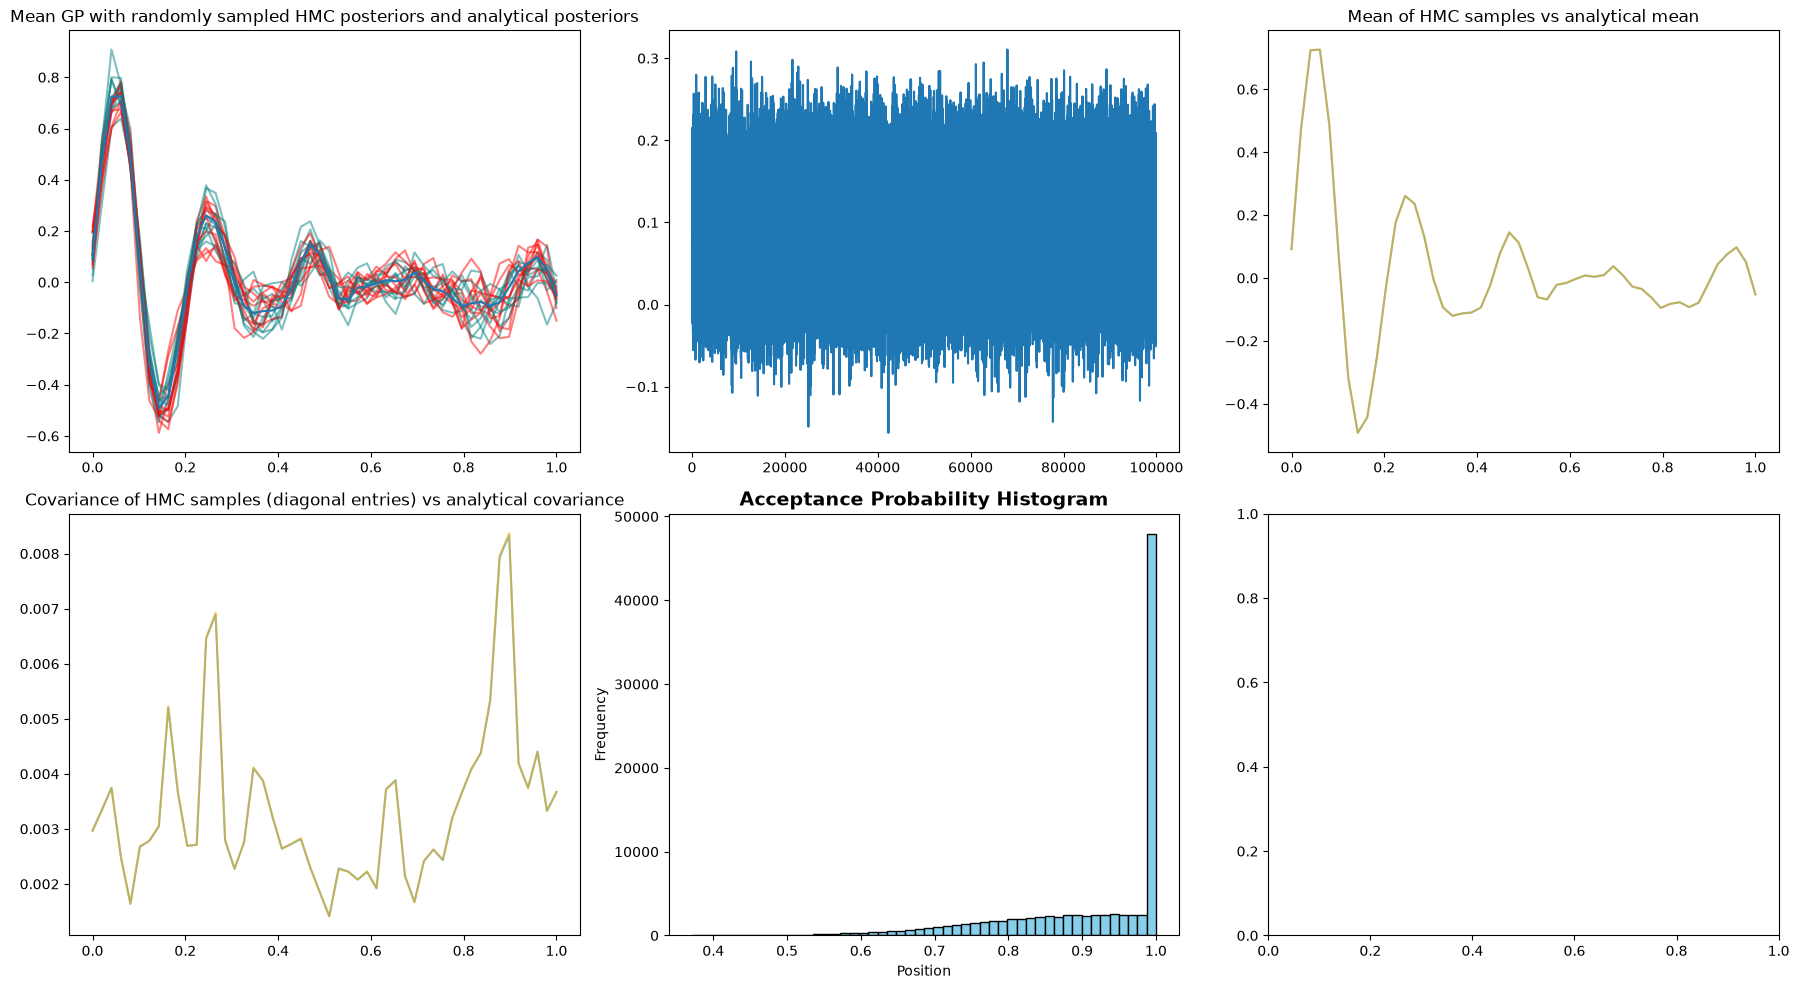

ESS for parameter 0: 113477.44350120812
KL_div using original mean/variances per dimension: 0.00015799229820047386 Normalized KL_div per dimension: 0.0001579922982013265


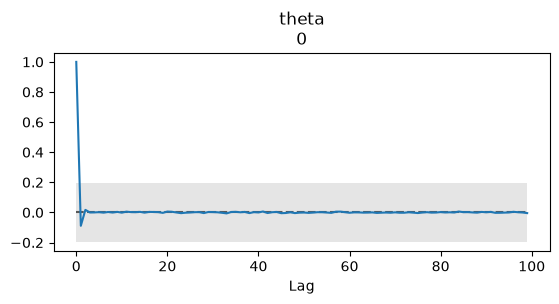

In [5]:
num_good_samples = num_overall_steps - burn_in


rng, key = jr.split(rng)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
mean_position = overall_position_arr.sum(axis=0)/num_good_samples
#axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
noise = jr.normal(key, shape = (num_dimensions, num_overall_steps))
noise_sample_from_posterior_array = M[:, None] + L_D @ noise




HMC_sample_mean = jnp.average(overall_position_arr, axis=0)
cov_HMC_data = jnp.cov(overall_position_arr,rowvar = False)
normalized_HMC_data = (jnp.linalg.solve(L_D, overall_position_arr.T - M[:, None])).T
mean_normalized_HMC_data = jnp.average(normalized_HMC_data, axis = 0)
cov_normalized_HMC_data = jnp.cov(normalized_HMC_data, rowvar = False)
cov_random_posterior_samples = jnp.cov(noise_sample_from_posterior_array.T, rowvar = False)
KL_div = KL_div_between_two_Gaussians(M, D, HMC_sample_mean, cov_HMC_data, num_dimensions)
KL_div_normalized = KL_div_between_two_Gaussians(jnp.zeros(num_dimensions), jnp.eye(num_dimensions), mean_normalized_HMC_data, cov_normalized_HMC_data, num_dimensions)

diag_cov_HMC_data = jnp.diag(cov_HMC_data)
diag_analytical_cov_HMC_data = jnp.diag(D)

for i in range (0, 10):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[100*i, :], color = "teal", alpha = 0.5);
    axes[0][0].plot(fixed_points_linspace, noise_sample_from_posterior_array[:, i], color = "red", alpha = 0.5)
axes[0][0].plot(fixed_points_linspace, M)
axes[0][0].set_title("Mean GP with randomly sampled HMC posteriors and analytical posteriors")

time_arr = jnp.arange(num_good_samples)
axes[0][1].plot(time_arr, overall_position_arr[:, 0])
axes[0][2].plot(fixed_points_linspace, mean_position, color = "teal", alpha = 0.5)
axes[0][2].plot(fixed_points_linspace, M, color = "orange", alpha = 0.5)
axes[0][2].set_title("Mean of HMC samples vs analytical mean")
axes[1][0].plot(fixed_points_linspace, diag_cov_HMC_data, color = "teal", alpha = 0.5)
axes[1][0].plot(fixed_points_linspace, diag_analytical_cov_HMC_data, color = "orange", alpha = 0.5)
axes[1][0].set_title("Covariance of HMC samples (diagonal entries) vs analytical covariance")
axes[1][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[1][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Position')
axes[1][1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

#overall_position_arr shape: (num_samples, 50) -- (draw, dimension)
posterior_samples = overall_position_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})
param_index = 0  # which of your 50 parameters you want

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

ess_param = ess_all["theta"].sel(theta_dim_0=param_index).values
print(f"ESS for parameter {param_index}: {ess_param}")
print(f"KL_div using original mean/variances per dimension: {KL_div/num_dimensions} Normalized KL_div per dimension: {KL_div_normalized/num_dimensions}")
# print(f"Covariance matrix of normalized HMC data (should be the identity): {cov_normalized_HMC_data}")



In [6]:
chi_2_residues_for_data = (R @ overall_position_arr.T).T - y_obs
normalized_chi_2_measurment = jnp.einsum('ij, jk, ik -> i', chi_2_residues_for_data, inv_cov_data_matrix, chi_2_residues_for_data)/num_data
normalized_chi_2_prior = jnp.einsum('ij, jk, ik -> i', overall_position_arr, inv_cov_prior_matrix, overall_position_arr)/num_dimensions
print(f"Average normalized chi_2 compared to the measurement: {jnp.average(normalized_chi_2_measurment)}")
print(f"Average normalized chi_2 compared to the prior: {jnp.average(normalized_chi_2_prior)}")

Average normalized chi_2 compared to the measurement: 0.8507787325126307
Average normalized chi_2 compared to the prior: 1.044137199957195
